# Tarea Semanal 3: Simulación de un ADC (cuantización) parte 1/2
**Autor:** Marco Trabattoni  
**Cátedra:** Procesamiento Digital de Señales - R6051  
**Docente:** Mariano Llamedo Soria
 
---
## 1. Introducción

En esta tarea simularemos el comportamiento de un **ADC** y cómo sus parámetros, tamaño de palabra de **B** bits y frecuencia de muestreo **fs** afectan a una señal (aproximadamente) analógica.

Para ello se puede analizar una **senoidal** con los siguientes parámetros:

* frecuencia $f_0$ arbitraria, por ejemplo $f_0 = f_s / N = \Delta_f$,
* **Potencia normalizada**, es decir unitaria.

Se pide diseñar un bloque *cuantizador* que opere sobre una señal discreta en tiempo $s_R$, de forma tal que para un ADC de B bits y rango $V_{FS} = 2 \cdot V_F$, el operador:

$$s_Q = \underset{B, V_{FS}}{Q} \{s_R\}$$

generará una $s_Q$ comprendida entre $\pm V_F$ y con valores discretos establecidos por el paso de cuantización $q = \frac{V_{FS}}{2^B}$ (Volts).

Visualice en una misma gráfica $s_R$ y $s_Q$, donde se pueda observar que tienen **el mismo rango** en Volts y el efecto de la cuantización para $V_F = 2$ Volts y $B = 4, 8$ y $16$ bits.

### **Bonus:**

* 🤯 Analizar la señal de error $e = s_Q - s_R$ verificando las descripciones estadísticas vistas en teoría (Distribución uniforme, media, varianza, incorrelación).



## 2. Configuración
En esta sección se importan las librerías necesarias (`numPy` y `matplotlib.pyplot`) y se definen tanto los algoritmos de trabajo, como los parámetros globales de la simulación (frecuencia de muestreo, frecuencias de las señales, bits del ADC, etc).

In [15]:
# Importación de módulos que utilizaremos en esta tarea semanal 3:
import matplotlib.pyplot as plt
import numpy as np

#%%  ALGORITMO DFT
def mi_funcion_DFT(xx):
    N = len(xx)
    n = np.arange(N)
    k = n.reshape((N, 1))
    
    matriz_exponencial = np.exp(-2j * np.pi * k * n / N)
    
    XX = np.dot(matriz_exponencial, xx)
    
    return XX

#%% Cuantizador
def cuantizador(Xd, B, Vf):
    Vfs = 2 * Vf
    q = Vfs / (2**B) 
    
    Xq = np.round(Xd / q) * q
    
    Xq = np.clip(Xq, -Vf, Vf - q)
    
    return Xq


#%%  Definicion de mi señal senoidal (TS1)
def MT_Senoidal(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=100):
    
    """
    Genera una señal senoidal con los siguientes argumentos:
        
    vmax -- Amplitud máxima (Volts)
    dc   -- Valor medio (Volts)
    ff   -- Frecuencia de la senoidal (Hz)
    ph   -- Fase (Radianes)
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo (Hz)
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    
    # Calculamos el intervalo entre muestras (periodo de muestreo)
    ts = 1/fs
    
    # Generamos el vector de tiempo tt
    tt = np.arange(0.0, N*ts, ts)
    
    # Generamos el vector de señal xx con ruido
    ruido_analogico = 0.125 * np.random.randn(len(tt))
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc + ruido_analogico
    
    return tt, xx


#%% Parámetros
VF = 2
fs = 1000
N = 1000
f0 = 4

t, Xr  = MT_Senoidal(vmax=np.sqrt(2), dc=0, ff=f0, ph=0, nn=N, fs=fs)

bits_list = [4, 8, 16]

## 3. Generación y Visualización de Señales
Se procede a instanciar las señales utilizando las funciones definidas anteriormente y se grafican para verificar su correcto funcionamiento en el dominio del tiempo.

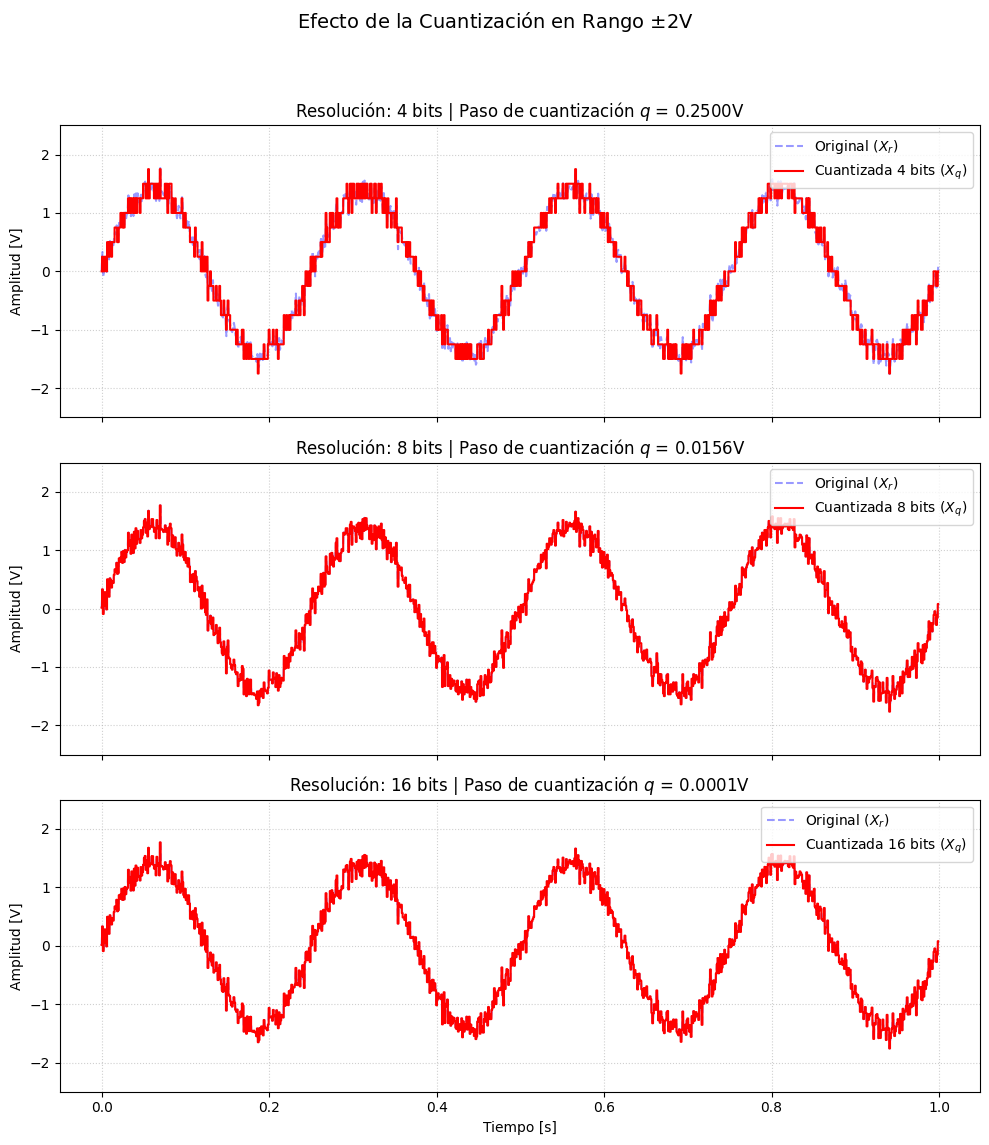

<Figure size 640x480 with 0 Axes>

In [16]:
#%% --- Gráfica ---
fig, axs = plt.subplots(len(bits_list), 1, figsize=(10, 12), sharex=True)
fig.suptitle(f'Efecto de la Cuantización en Rango $\pm${VF}V', fontsize=14)

for i, B in enumerate(bits_list):
    Xq = cuantizador(Xr, B, VF)
    q = (2 * VF) / (2**B)
    
    # Graficamos la original y la cuantizada en cada subplot
    axs[i].plot(t, Xr, label='Original ($X_r$)', alpha=0.4, color='blue', linestyle='--')
    axs[i].step(t, Xq, label=f'Cuantizada {B} bits ($X_q$)', where='mid', color='red')
    
    # Detalles estéticos
    axs[i].set_title(f'Resolución: {B} bits | Paso de cuantización $q$ = {q:.4f}V')
    axs[i].set_ylabel('Amplitud [V]')
    axs[i].set_ylim(-VF - 0.5, VF + 0.5) # Mismo rango para todos
    axs[i].grid(True, linestyle=':', alpha=0.6)
    axs[i].legend(loc='upper right')

axs[-1].set_xlabel('Tiempo [s]')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## 4. Bonus



--- CÁLCULO DE LA SNR (B=6) ---
SNR Medida: 34.84 dB
SNR Teórica: 37.88 dB

--- ESTADÍSTICAS DEL ERROR (B=6) ---
Media: -0.000674 (Teórica: 0)
Varianza Medida: 0.000334
Varianza Teórica (q^2/12): 0.000326


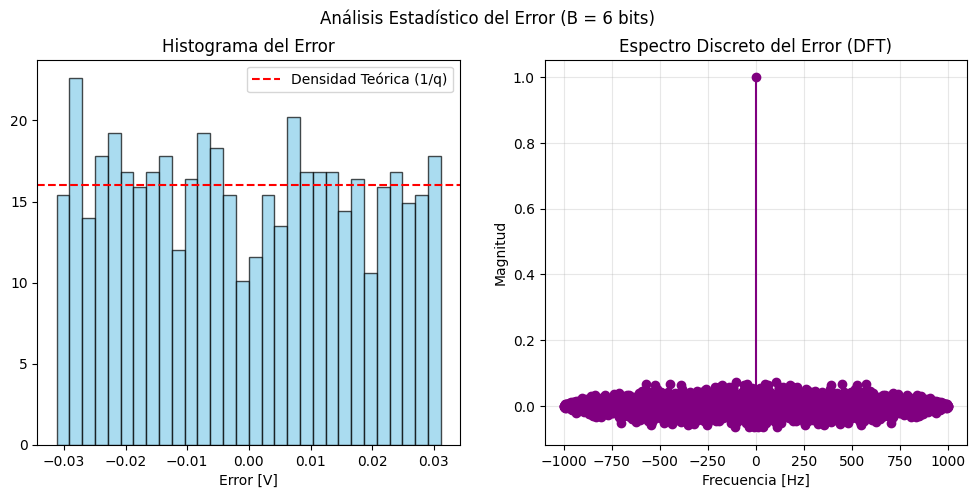

In [17]:
#%% NUEVA SECCIÓN: ANÁLISIS ESTADÍSTICO DEL ERROR (Bonus)
B_analisis = 6
q_analisis = (2 * VF) / (2**B_analisis)
Xq_analisis = cuantizador(Xr, B_analisis, VF)
error = Xq_analisis - Xr

#%% --- CÁLCULO DE SNR ---
potencia_señal = np.var(Xr)  # Si tiene media 0, la varianza es la potencia
potencia_ruido = np.var(error)

snr_medida = 10 * np.log10(potencia_señal / potencia_ruido)

# SNR Teórica para un ADC (6.02*B + 1.76 dB)
snr_teorica = 6.02 * B_analisis + 1.76

print(f"\n--- CÁLCULO DE LA SNR (B={B_analisis}) ---")
print(f"SNR Medida: {snr_medida:.2f} dB")
print(f"SNR Teórica: {snr_teorica:.2f} dB")

#%% Cálculos de Media y Varianza
media_e = np.mean(error)
var_e_medida = np.var(error)
var_e_teorica = (q_analisis**2) / 12

print(f"\n--- ESTADÍSTICAS DEL ERROR (B={B_analisis}) ---")
print(f"Media: {media_e:.6f} (Teórica: 0)")
print(f"Varianza Medida: {var_e_medida:.6f}")
print(f"Varianza Teórica (q^2/12): {var_e_teorica:.6f}")

#%% Gráficas de distribución e incorrelación
fig_error, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig_error.suptitle(f'Análisis Estadístico del Error (B = {B_analisis} bits)')

# Histograma para ver la Distribución Uniforme
ax1.hist(error, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axhline(1/q_analisis, color='red', linestyle='--', label=f'Densidad Teórica (1/q)')
ax1.set_title('Histograma del Error')
ax1.set_xlabel('Error [V]')
ax1.legend()

# Autocorrelación para ver la Incorrelación
# Normalizamos la correlación para que el máximo sea 1
autocorr = np.correlate(error - media_e, error - media_e, mode='full')
autocorr = autocorr / np.max(autocorr)
lags = np.arange(-len(error) + 1, len(error))


ax2.stem(lags, autocorr, linefmt='purple', markerfmt='purple', basefmt=' ')
ax2.set_title('Espectro Discreto del Error (DFT)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Magnitud')
ax2.grid(True, alpha=0.3)

plt.show()


## 5. Análisis Frecuencial


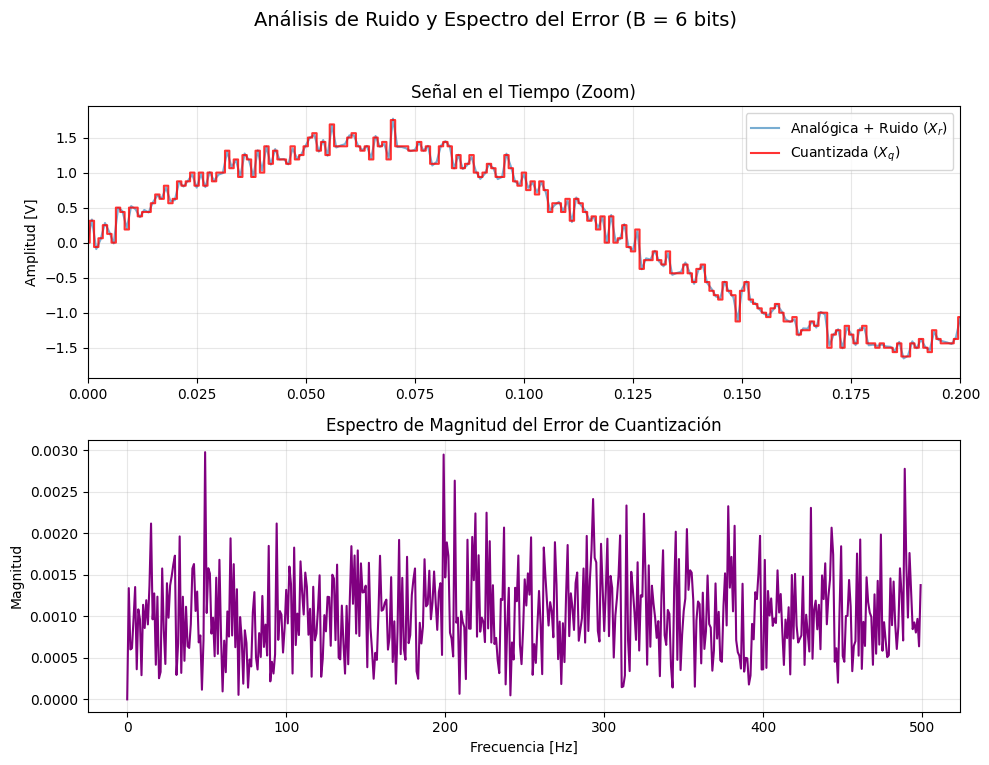

In [18]:
#%% --- CÁLCULO DEL ESPECTRO DEL ERROR (FFT) ---

df = fs / N 

# yf = np.fft.fft(error - np.mean(error))
# f_eje = np.arange(0, fs, df)
# xf = f_eje[:N//2]
# espectro_error = 2.0/N * np.abs(yf[:N//2])

#%% --- CÁLCULO DEL ESPECTRO DEL ERROR (DFT) ---

yf_dft = mi_funcion_DFT(error - np.mean(error))
f_eje = np.arange(0, fs, df)    
xf = f_eje[:N//2]
espectro_error = 2.0/N * np.abs(yf_dft[:N//2])

#%% --- GRÁFICAS ---
fig_bonus, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig_bonus.suptitle(f'Análisis de Ruido y Espectro del Error (B = {B_analisis} bits)', fontsize=14)

# Señal en el tiempo (Zoom para ver el ruido)
ax1.plot(t, Xr, label='Analógica + Ruido ($X_r$)', alpha=0.6)
ax1.step(t, Xq_analisis, label='Cuantizada ($X_q$)', where='mid', color='red', alpha=0.8)
ax1.set_xlim(0, 0.2) # Zoom inicial para ver los escalones y el ruido
ax1.set_title('Señal en el Tiempo (Zoom)')
ax1.set_ylabel('Amplitud [V]')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Espectro de Frecuencia del Error
ax2.plot(xf, espectro_error, color='purple')
ax2.set_title('Espectro de Magnitud del Error de Cuantización')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Magnitud')
ax2.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()